# --- Data Cleaning & Examination ---

In [1]:
# --- Imports --- 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
# --- Resolving Package Path ---
notebook_dir = Path.cwd()
src_path = (notebook_dir / ".." / "src").resolve()
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
# --- Importing API Files ---
from random_forest.utils import train_test_split

In [2]:
# --- Reading the Dataset --- 
data_frame = pd.read_csv(r'..\data\raw\transactions_dataset_v3.csv')
index_list=[i for i in range(1,len(data_frame)+1)]
data_frame.index=index_list
raw_data_amount=len(data_frame)
# --- Repersenting the Dataset ---
data_frame.iloc[:5,] #> Showing some part of te dataframe

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering
1,00:00:00,2024-01-01,75682867,78548252,20654.26,UK pounds,UK pounds,Turkey,India,ACH,1
2,00:01:00,2024-01-01,66755036,60373415,56453.82,US dollar,US dollar,UAE,Pakistan,Cross-border,1
3,00:02:00,2024-01-01,66882282,39679610,3301.28,Indian rupee,Indian rupee,Morocco,Italy,Cheque,0
4,00:03:00,2024-01-01,31081788,46161210,7848.25,Euro,Euro,India,Austria,Cross-border,0
5,00:04:00,2024-01-01,23315092,63958064,52097.64,Mexican peso,Mexican peso,Nigeria,Mexico,Cross-border,1


In [3]:
# --- Data Cleaning (First Stage) ---
del data_frame["Date"], data_frame["Sender_account"], data_frame["Receiver_account"]
print("The amount of 1: ", len(data_frame[data_frame['Is_laundering']==1]))
print("The amount of 0: ", len(data_frame[data_frame['Is_laundering']==0]))
# --- Checking for NaN Values ---
if len(data_frame) ==len(data_frame.dropna()):
    print("Dataset Has no 'NaN' Values.")
else:
    print("Dataset Needs Cleaning.")   

The amount of 1:  119848
The amount of 0:  280152
Dataset Has no 'NaN' Values.


In [4]:
# --- Data Cleaning (Second Stage) ---
#> Convert string to datetime first
data_frame["Time"] = pd.to_datetime(data_frame["Time"], format="%H:%M:%S")
# --- Extract hour ---
data_frame["Time"] = data_frame["Time"].dt.hour
# --- Repersenting the Dataset ---
data_frame.iloc[:8,]

,Time,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering
1,0,20654.26,UK pounds,UK pounds,Turkey,India,ACH,1
2,0,56453.82,US dollar,US dollar,UAE,Pakistan,Cross-border,1
3,0,3301.28,Indian rupee,Indian rupee,Morocco,Italy,Cheque,0
4,0,7848.25,Euro,Euro,India,Austria,Cross-border,0
5,0,52097.64,Mexican peso,Mexican peso,Nigeria,Mexico,Cross-border,1
6,0,42638.56,Yen,Yen,Morocco,Mexico,Cross-border,1
7,0,7624.38,Dirham,Dirham,Pakistan,Mexico,Debit card,0
8,0,45886.90,Swiss franc,Swiss franc,Turkey,USA,ACH,1


In [5]:
# --- Saving the Processed Dataset --- 
data_frame.to_csv(r'..\data\processed\processed_transactions_dataset_v3.csv', index=False)

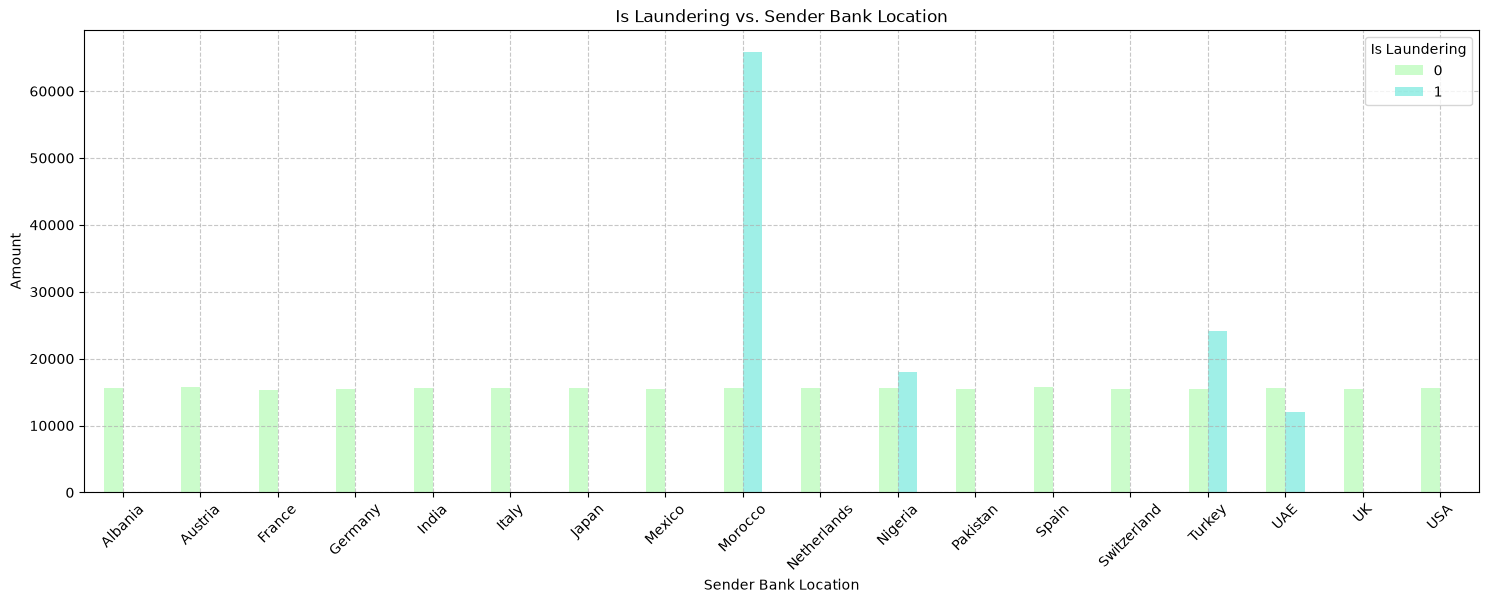

In [6]:
# --- Plot 1 ---
variation = pd.crosstab(data_frame.sort_values('Sender_bank_location')['Sender_bank_location'],
                        data_frame.sort_values('Sender_bank_location')['Is_laundering'])

variation.plot(kind="bar", figsize=(18,6), color = ["palegreen", "turquoise"], alpha=0.5)
plt.title('Is Laundering vs. Sender Bank Location')
plt.xticks(rotation=45)
plt.xlabel('Sender Bank Location')
plt.ylabel('Amount')
plt.legend(title="Is Laundering")
plt.grid(True, linestyle='--', alpha=0.7)

# --- Display and Saving the Plot ---
plt.savefig(r"..\results\figures\Sender_bank_location_vsIs_laundering_plot.png", dpi=300)
plt.show()
plt.close()

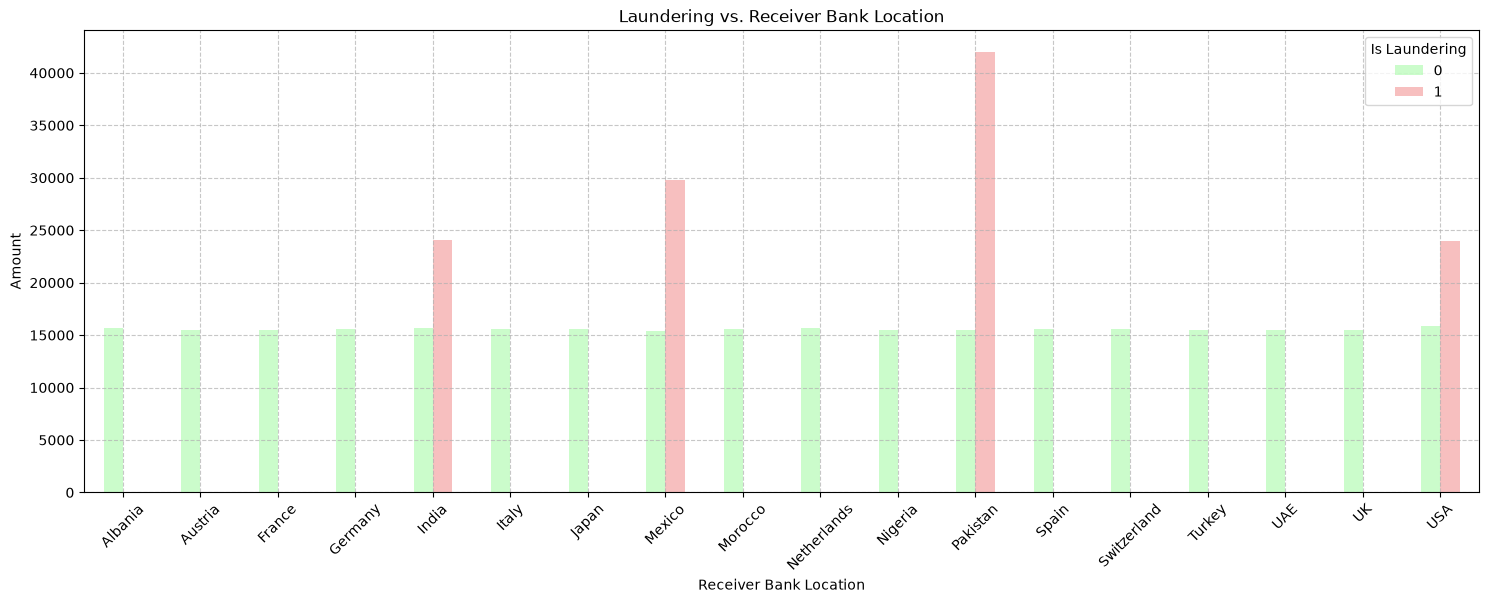

In [7]:
# --- Plot 2 ---

variation = pd.crosstab(data_frame.sort_values('Receiver_bank_location')['Receiver_bank_location'],
                        data_frame.sort_values('Receiver_bank_location')['Is_laundering'])

variation.plot(kind="bar", figsize=(18,6), color = ["palegreen", "lightcoral"], alpha=0.5)
plt.title('Laundering vs. Receiver Bank Location')
plt.xticks(rotation=45)
plt.xlabel('Receiver Bank Location')
plt.ylabel('Amount')
plt.legend(title="Is Laundering")
plt.grid(True, linestyle='--', alpha=0.7)

# --- Display and Saving the Plot ---
plt.savefig(r"..\results\figures\Receiver_bank_location_vs_Is_laundering_plot.png", dpi=300)
plt.show()
plt.close()

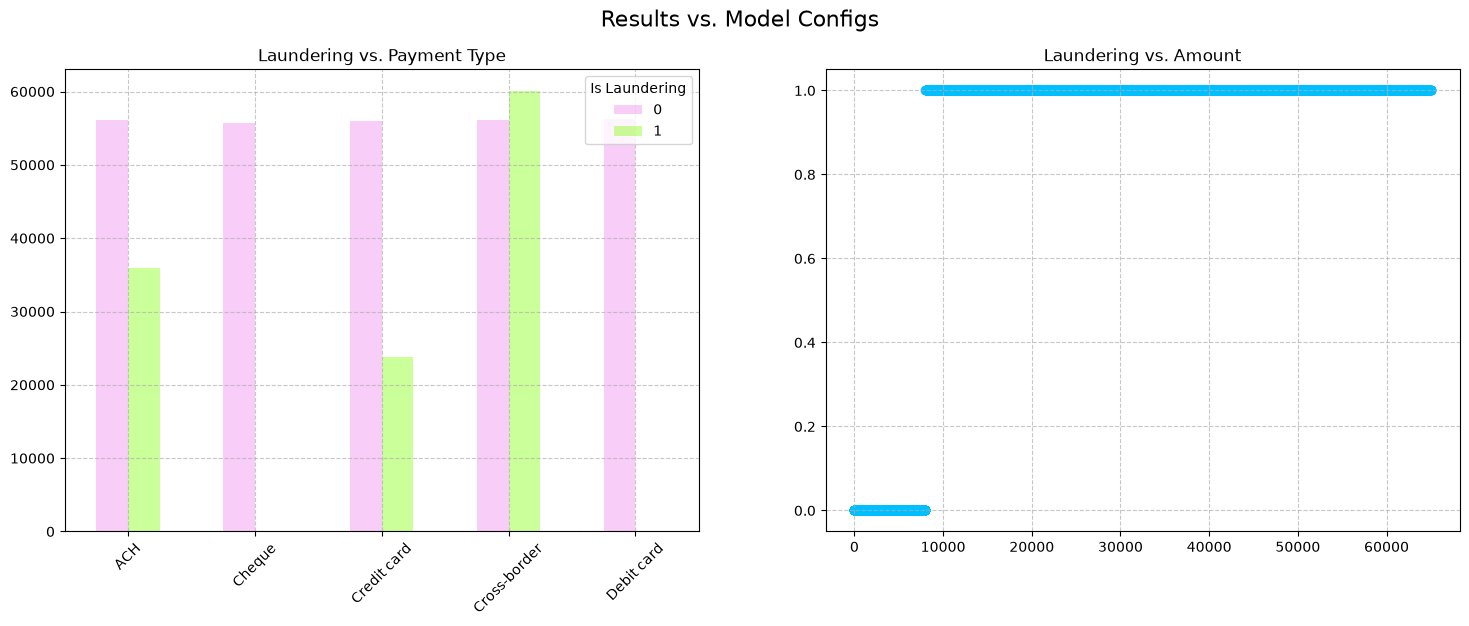

In [8]:
# --- Plot 3 ---

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Results vs. Model Configs', fontsize=16)

variation = pd.crosstab(data_frame["Payment_type"], data_frame["Is_laundering"])
variation.plot(kind="bar", ax=ax[0], color=["violet", "chartreuse"], alpha=0.4)
ax[0].set_title('Laundering vs. Payment Type')
ax[0].set_xlabel("")
ax[0].tick_params(axis='x', rotation=45)
ax[0].grid(True, linestyle='--', alpha=0.7)
ax[0].legend(title="Is Laundering")

ax[1].scatter(data_frame['Amount'], data_frame['Is_laundering'], color="deepskyblue", alpha=0.03)
ax[1].set_title('Laundering vs. Amount')
ax[1].set_xlabel("")
ax[1].grid(True, linestyle='--', alpha=0.7)

# --- Display and Saving the Plot ---
plt.savefig(r"..\results\figures\Payment_type_&_Amount_plot.png", dpi=300)
plt.show()
plt.close()

In [9]:
# --- Saving Train-Ready Splits ---
Y = data_frame["Is_laundering"].to_numpy()
del data_frame["Is_laundering"]
X = data_frame.to_numpy()
del data_frame
# --- Splitting ---
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=42)
# --- Saving ---
np.save(r"..\\data\\splits\\transactions\\x_train", x_train)
np.save(r"..\\data\\splits\\transactions\\x_test", x_test)
np.save(r"..\\data\\splits\\transactions\\y_train", y_train)
np.save(r"..\\data\\splits\\transactions\\y_test", y_test)
# --- Clean up ---
del X, Y
del x_train, x_test, y_train, y_test